# Chunk 36 — Gupta-style fixed 25×25 CNN

This is a pre-registered 25×25-only reproduction of the forward CNN in Gupta *et al.* (IEEE TAP, 2023, Fig. 4). It writes only `ch36_*` artifacts and `checkpoints/ch36_gupta_cnn25*.pt`. Every code cell below is preceded by a markdown cell stating its purpose and write contract.

## 1. Install runtime dependencies

Installs the graph/parquet dependencies used to load frozen comparison models and write the requested artifacts. It writes only to the Colab environment, not Drive.

In [1]:
!pip -q install torch_geometric pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.7 MB/s eta 0:00:00


## 2. Clone the repository and mount Drive

Clones or fast-forwards the repository, adds `src` to `sys.path`, mounts Google Drive, and defines the standard data root. It writes only `/content/antenna_gnn` and the Drive mount metadata.

In [2]:
import os, sys, subprocess
REPO_ROOT = '/content/antenna_gnn'
if os.path.isdir(f'{REPO_ROOT}/.git'):
    subprocess.run(['git', '-C', REPO_ROOT, 'pull', '-q'], check=True)
else:
    subprocess.run(['git', 'clone', '-q', 'https://github.com/asparagusD/antenna_gnn.git', REPO_ROOT], check=True)
sys.path.insert(0, f'{REPO_ROOT}/src')
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
print('repo:', REPO_ROOT, '| data:', DATA_ROOT)

Mounted at /content/drive
repo: /content/antenna_gnn | data: /content/drive/MyDrive/antenna_gnn


## 3. Lock the experimental contract and capture provenance

Defines the 25×25-only guard, deterministic CUDA settings, output-path gate, and immutable-input audit. It writes no artifact yet; later cells use `OUT`/`CKOUT` so no non-Chunk-36 output can be created. The pre-registered rules are raw-dB targets, MSE, NAdam at 1e-3, batch 256, and a fixed −10 dB classifier threshold.

In [3]:
import os, json, glob, hashlib, shutil, zipfile, time, random
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import AntennaGNN
from feed_component import AppendFeedComponentFeature

GRID, N_OUT, FIXED_TAU = 25, 201, -10.0
assert GRID == 25
ART, CKPT = f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints'
os.makedirs(ART, exist_ok=True); os.makedirs(CKPT, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type == 'cuda', 'GPU required for the 160M-parameter fixed CNN'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False; torch.backends.cudnn.allow_tf32 = False

def digest(p):
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(1 << 20), b''): h.update(b)
    return h.hexdigest()

def OUT(name):
    assert name.startswith('ch36_'), f'non-ch36 artifact refused: {name}'
    return f'{ART}/{name}'
def CKOUT(name):
    assert name.startswith('ch36_gupta_cnn25') and name.endswith('.pt'), name
    return f'{CKPT}/{name}'

# Hash every file read; capture mtimes of all pre-existing checkpoints and ch28–ch35 artifacts.
PRIOR = [p for pat in (f'{ART}/ch2[89]_*', f'{ART}/ch3[0-5]_*', f'{CKPT}/*.pt') for p in glob.glob(pat)
         if os.path.isfile(p) and not Path(p).name.startswith('ch36_')]
PRIOR_MTIME = {p: os.path.getmtime(p) for p in PRIOR}
READ_SHA = {}
def READ(p):
    assert os.path.exists(p), f'missing required input: {p}'
    READ_SHA.setdefault(p, digest(p)); return p
GRAPH_LOADS = 0
TEST_TOUCHES = 0
WRITTEN = []
print(f'GPU={torch.cuda.get_device_name(0)}; captured {len(PRIOR_MTIME)} immutable mtimes')

GPU=NVIDIA A100-SXM4-40GB; captured 70 immutable mtimes


## 4. Read and reconcile the 25×25 split

Reads `splits/indices.json` only for train/validation/test membership, filters strictly to grid 25, and checks validation/test local indices against the Chunk 28 cache. It may read `cnn_split_indices.json` only to define the later clean evaluation subset; it is never used for training. This cell writes nothing.

In [5]:
def pairs(v):
    if isinstance(v, dict): return {(int(g), int(i)) for g, xs in v.items() for i in xs}
    return {(int(g), int(i)) for g, i in v}

indices_path = READ(f'{DATA_ROOT}/splits/indices.json')
idx = json.load(open(indices_path))
SPLIT = {role: sorted(i for g, i in pairs(idx[role]) if g == GRID) for role in ('train', 'val', 'test')}
assert all(len(v) for v in SPLIT.values())
assert not (set(SPLIT['train']) & set(SPLIT['val']) or set(SPLIT['train']) & set(SPLIT['test']) or set(SPLIT['val']) & set(SPLIT['test']))
P28 = pd.read_parquet(READ(f'{ART}/ch28_per_sample.parquet'))
P28 = P28[(P28.model_id == 'best_model') & (P28.grid_size == GRID)]
for role, tag in (('val', '25x25_val'), ('test', '25x25_test')):
    got = set(SPLIT[role]); ref = set(P28[P28.split == tag].local_idx.astype(int))
    assert got == ref, f'STOP: {role} differs from Chunk 28: {len(got ^ ref)} indices'
assert len(SPLIT['test']) == 9983, f'expected 9,983 test graphs, got {len(SPLIT["test"])}'
cnn_split = json.load(open(READ(f'{DATA_ROOT}/splits/cnn_split_indices.json')))
cnn_seen = set(map(int, cnn_split['train'])) | set(map(int, cnn_split['val']))
CLEAN = sorted(set(SPLIT['test']) - cnn_seen)
assert len(CLEAN) == 1048, f'expected 1,048 clean test graphs, got {len(CLEAN)}'
print({k: len(v) for k,v in SPLIT.items()}, '| clean test:', len(CLEAN))

{'train': 79866, 'val': 9984, 'test': 9983} | clean test: 1048


## 5. Stage and preload only 25×25 graph data

Unzips `processed_25x25.zip` to local SSD, validates raw-dB graph labels and the virtual-node contract, converts each graph to a `(1,25,25)` binary image, and preloads the fixed split into float32 tensors. It writes only the temporary `/content/ch36_tensors_25x25.pt` cache, never Drive.

In [6]:
LOCAL = '/content/local_graphs/25x25'
MARKER = f'{LOCAL}/_STAGED.txt'
ZIP = READ(f'{DATA_ROOT}/data/processed/processed_25x25.zip')
if not os.path.exists(MARKER):
    os.makedirs(LOCAL, exist_ok=True)
    with zipfile.ZipFile(ZIP) as zf:
        members = [m for m in zf.namelist() if m.endswith('.pt')]
        for m in tqdm(members, desc='staging 25x25 graphs'):
            with zf.open(m) as src, open(f'{LOCAL}/{os.path.basename(m)}', 'wb') as dst: shutil.copyfileobj(src, dst)
    open(MARKER, 'w').write(f'{len(members)}\n')

def load_graph(i):
    global GRAPH_LOADS
    assert GRID == 25, 'no non-25 graph may be loaded'
    GRAPH_LOADS += 1
    return torch.load(f'{LOCAL}/sample_{int(i)}.pt', weights_only=False)

def as_image_target(i):
    d = load_graph(i); x, y = d.x, d.y.reshape(-1).float()
    assert x.shape[0] == GRID * GRID + 1 and x[-1, 3].item() == -1
    assert y.shape == (N_OUT,) and float(y.max()) <= 0.01, 'on-disk y must be raw dB'
    image = x[:-1, 0].reshape(1, GRID, GRID).float()
    assert torch.all((image == 0) | (image == 1)), 'CNN input must be binary metal pattern'
    return image, y

CACHE = '/content/ch36_tensors_25x25.pt'
cache_ok = os.path.exists(CACHE)
if cache_ok:
    T = torch.load(CACHE, map_location='cpu', weights_only=False)
    cache_ok = T.get('split') == SPLIT and T['train'][0].dtype == torch.float32
if not cache_ok:
    T = {'split': SPLIT}
    for role in ('train', 'val', 'test'):
        a = [as_image_target(i) for i in tqdm(SPLIT[role], desc=f'preload {role}')]
        T[role] = (torch.stack([q[0] for q in a]), torch.stack([q[1] for q in a]))
    torch.save(T, CACHE)
for role in ('train', 'val', 'test'):
    X, Y = T[role]; assert X.shape == (len(SPLIT[role]), 1, 25, 25) and Y.shape == (len(SPLIT[role]), 201)
print('preloaded:', {r: tuple(T[r][0].shape) for r in ('train','val','test')}, '| graph loads:', GRAPH_LOADS)

staging 25x25 graphs:   0%|          | 0/99833 [00:00<?, ?it/s]

preload train:   0%|          | 0/79866 [00:00<?, ?it/s]

preload val:   0%|          | 0/9984 [00:00<?, ?it/s]

preload test:   0%|          | 0/9983 [00:00<?, ?it/s]

preloaded: {'train': (79866, 1, 25, 25), 'val': (9984, 1, 25, 25), 'test': (9983, 1, 25, 25)} | graph loads: 99833


## 6. Define the frozen Gupta forward CNN

Copies Chunk 3's convolutional stack verbatim and replaces only adaptive pooling with flattening at 25×25. It asserts the pre-registered trainable-parameter count; on a mismatch it prints per-layer counts and stops. It writes nothing.

In [7]:
class GuptaCNN25(nn.Module):
    """Gupta et al. Fig. 4 forward CNN, fixed for 25x25 and 201 outputs."""
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2),
            nn.Conv2d(64,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2),
            nn.Conv2d(64,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2))
        b2 = [nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        for _ in range(4): b2 += [nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        self.block2 = nn.Sequential(*b2)
        b3 = [nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        for _ in range(7): b3 += [nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        self.block3 = nn.Sequential(*b3)
        self.fc = nn.Sequential(nn.Linear(256*25*25,1000), nn.BatchNorm1d(1000), nn.LeakyReLU(.2), nn.Dropout(.4),
                                nn.Linear(1000,500), nn.BatchNorm1d(500), nn.LeakyReLU(.2), nn.Dropout(.4), nn.Linear(500,201))
    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x))).flatten(1))

def layer_counts(m): return [(n, sum(p.numel() for p in q.parameters(recurse=False))) for n,q in m.named_modules() if list(q.parameters(recurse=False))]
model = GuptaCNN25()
N_PARAM = sum(p.numel() for p in model.parameters())
if N_PARAM != 165_907_473:
    print('per-layer trainable parameter counts:')
    for n,c in layer_counts(model): print(f'{n:30s} {c:,}')
    raise AssertionError(f'STOP: expected 165,907,473 parameters, got {N_PARAM:,}')
assert model(torch.zeros(2,1,25,25)).shape == (2,201)
print(f'parameter guard passed: {N_PARAM:,}')

parameter guard passed: 165,907,473


## 7. Train with the fixed pre-registered recipe

Trains only on `indices.json` 25×25 train tensors; validation drives the scheduler, stopping rule, and primary selection. It writes the running checkpoint every epoch, the best validation checkpoint, the required epoch-15 secondary checkpoint, the CSV log, and training figure—all under Chunk 36 names. It times epoch 1 and aborts if the conservative 60-epoch projection exceeds three hours.

*(v2)* `BEST` and `EP15` now store the model only; the full ~2 GB running state lives on local SSD and is mirrored to Drive every 5 epochs and at the end. Early stopping cannot fire before epoch 15, so the secondary checkpoint always exists. A resumed run that had already stopped does not train further. After training, Drive is flushed and both checkpoints are re-verified.

auto-resumed at epoch 39


Training Epochs:   0%|          | 0/22 [00:00<?, ?it/s]

already early-stopped; not training further
Mounted at /content/drive
BEST and EP15 checkpoints verified on Drive after a forced flush


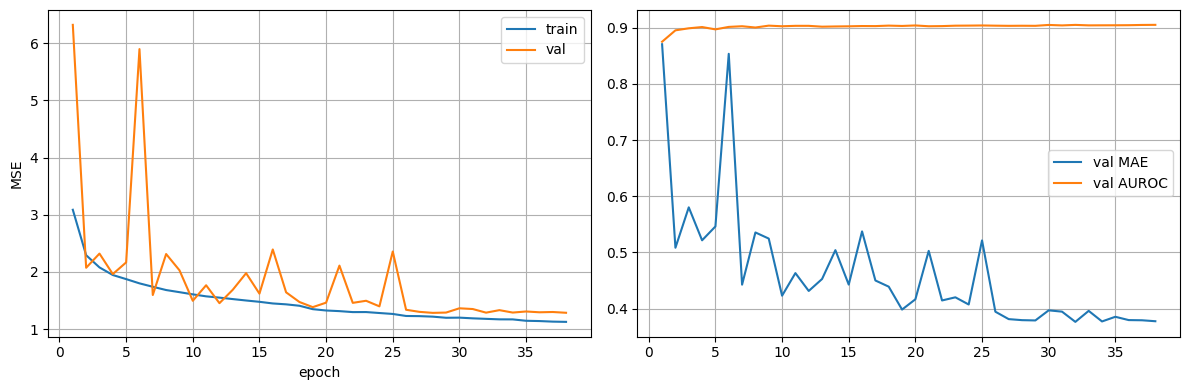

selected epoch 28: train/val MSE gap = -0.066019


In [9]:
BATCH, MAX_EPOCHS, PATIENCE = 256, 60, 10
RUNNING, BEST, EP15 = (CKOUT('ch36_gupta_cnn25_running.pt'), CKOUT('ch36_gupta_cnn25_best.pt'), CKOUT('ch36_gupta_cnn25_ep15.pt'))
train_loader = DataLoader(TensorDataset(*T['train']), batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(TensorDataset(*T['val']), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
model = model.to(DEVICE)
opt = torch.optim.NAdam(model.parameters(), lr=1e-3, weight_decay=0)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=.5, patience=5, min_lr=1e-6)
criterion = nn.MSELoss()

def rng_state(): return {'torch': torch.get_rng_state(), 'cuda': torch.cuda.get_rng_state_all(), 'numpy': np.random.get_state(), 'python': random.getstate()}
def set_rng(s):
    torch.set_rng_state(s['torch'].cpu()); torch.cuda.set_rng_state_all([state.cpu() for state in s['cuda']]); np.random.set_state(s['numpy']); random.setstate(s['python'])
# Checkpoint sizes: the model is 166M parameters (~0.66 GB); NAdam adds two moment tensors (~1.3 GB more).
# BEST and EP15 hold the MODEL only (+ metadata). The full RUNNING state (~2 GB) is written to local SSD every
# epoch and mirrored to Drive every MIRROR_EVERY epochs and at the end. Writing 2 GB to the Drive mount every
# epoch is slow and, as Chunk 30 showed, not durable unless flushed.
LOCAL_RUNNING = '/content/ch36_gupta_cnn25_running.pt'
MIRROR_EVERY = 5
def save_model_only(path, epoch, best_val, log):
    torch.save({'epoch':epoch,'model_state':model.state_dict(),'best_val':best_val,'log':log,'parameter_count':N_PARAM}, path)
def save_running(epoch, best_val, bad, log, mirror):
    torch.save({'epoch':epoch,'model_state':model.state_dict(),'optimizer_state':opt.state_dict(),'scheduler_state':sched.state_dict(),
                'best_val':best_val,'bad_epochs':bad,'log':log,'rng_state':rng_state(),'parameter_count':N_PARAM}, LOCAL_RUNNING)
    if mirror:
        shutil.copy(LOCAL_RUNNING, RUNNING)

start, best_val, bad, LOG = 1, float('inf'), 0, []
_resume = LOCAL_RUNNING if os.path.exists(LOCAL_RUNNING) else (RUNNING if os.path.exists(RUNNING) else None)
if _resume:
    c = torch.load(_resume, map_location=DEVICE, weights_only=False)
    assert c['parameter_count'] == N_PARAM
    model.load_state_dict(c['model_state']); opt.load_state_dict(c['optimizer_state']); sched.load_state_dict(c['scheduler_state']); set_rng(c['rng_state'])
    start, best_val, bad, LOG = c['epoch'] + 1, c['best_val'], c['bad_epochs'], c['log']
    print('auto-resumed at epoch', start)

def evaluate(loader):
    model.eval(); ss=sae=0.; P=[]; Y=[]
    with torch.no_grad():
        for x,y in tqdm(loader, desc='Evaluating', leave=False):
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); p=model(x); ss += ((p-y)**2).sum().item(); sae += (p-y).abs().sum().item(); P.append(p.cpu()); Y.append(y.cpu())
    p,y=torch.cat(P),torch.cat(Y); label=(y.min(1).values < FIXED_TAU).numpy(); score=(-p.min(1).values).numpy()
    auc=roc_auc_score(label,score) if label.min()!=label.max() else float('nan')
    return ss/y.numel(), sae/y.numel(), auc

MIN_EPOCHS = 15   # the epoch-15 secondary checkpoint must exist; early stopping cannot fire before it
epoch_bar = tqdm(range(start, MAX_EPOCHS + 1), desc='Training Epochs')
for epoch in epoch_bar:
    if bad >= PATIENCE and epoch > MIN_EPOCHS:   # resuming a run that had already stopped
        print('already early-stopped; not training further'); break
    t0=time.perf_counter(); model.train(); total=0.
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch} Batches', leave=False)
    for x,y in train_bar:
        x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True); opt.zero_grad(set_to_none=True); loss=criterion(model(x),y); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); total += loss.item()*len(x)
        train_bar.set_postfix(loss=loss.item())
    train_mse=total/len(T['train'][0]); val_mse,val_mae,val_auc=evaluate(val_loader); sched.step(val_mse)
    row={'epoch':epoch,'train_mse':train_mse,'val_mse':val_mse,'val_mae':val_mae,'val_auroc':val_auc,'lr':opt.param_groups[0]['lr'],'seconds':time.perf_counter()-t0}; LOG.append(row)
    pd.DataFrame(LOG).to_csv(OUT('ch36_train_log.csv'),index=False)
    if epoch == 1:
        projected=row['seconds']*MAX_EPOCHS/3600; print(f'epoch 1: {row["seconds"]/60:.1f} min; worst-case 60-epoch projection {projected:.2f} h'); assert projected <= 3, 'STOP: projected training exceeds 3 hours'
    if val_mse < best_val:
        best_val,bad=val_mse,0; save_model_only(BEST,epoch,best_val,LOG)
    else: bad += 1
    if epoch == 15: save_model_only(EP15,epoch,best_val,LOG)
    stopping = bad >= PATIENCE and epoch >= MIN_EPOCHS
    save_running(epoch,best_val,bad,LOG, mirror=(epoch % MIRROR_EVERY == 0) or stopping or epoch == MAX_EPOCHS)
    epoch_bar.set_postfix(train_mse=f'{train_mse:.5f}', val_mse=f'{val_mse:.5f}')
    print(f'E{epoch:02d} train={train_mse:.5f} val={val_mse:.5f} MAE={val_mae:.4f} AUROC={val_auc:.4f} lr={row["lr"]:.1e}')
    if stopping: print('early stopping'); break
assert os.path.exists(BEST) and os.path.exists(EP15), 'epoch-15 checkpoint must exist; resume or train through epoch 15'
# Durability (Chunk 30 lesson): force Drive to persist the checkpoints, remount, and verify their contents.
from google.colab import drive as _drive
_local_sha = {p: digest(p) for p in (BEST, EP15)}
_drive.flush_and_unmount(); _drive.mount('/content/drive', force_remount=True)
for p, h in _local_sha.items():
    assert digest(p) == h, f'STOP: {Path(p).name} did not persist on Drive'
print('BEST and EP15 checkpoints verified on Drive after a forced flush')
L=pd.DataFrame(LOG); best_epoch=int(torch.load(BEST,map_location='cpu',weights_only=False)['epoch']); selected=L[L.epoch==best_epoch].iloc[0]
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].plot(L.epoch,L.train_mse,label='train'); ax[0].plot(L.epoch,L.val_mse,label='val'); ax[0].set(xlabel='epoch',ylabel='MSE'); ax[0].legend(); ax[0].grid(); ax[1].plot(L.epoch,L.val_mae,label='val MAE'); ax[1].plot(L.epoch,L.val_auroc,label='val AUROC'); ax[1].legend(); ax[1].grid(); fig.tight_layout(); fig.savefig(OUT('ch36_training_curves.png'),dpi=180); plt.show()
print(f'selected epoch {best_epoch}: train/val MSE gap = {selected.train_mse-selected.val_mse:+.6f}')

## 8. Load frozen comparison models and validate on validation data

Loads `best_model`, `backbone_no55`, and `cnn_best` exactly with the Chunk 35 architecture/state conventions, while loading the two new CNN checkpoints as raw-dB predictors. It validates all existing-model minima on the 25×25 validation set against Chunk 35 before any test graph is inferred. It writes nothing.

*(v2)* `cnn_best` is loaded with its own pooled Chunk 3 architecture (`AntennaCNN`, 6,163,473 parameters). The draft loaded it into `GuptaCNN25`, which would have failed strict loading.

*(v3)* The reproduction check now uses per-model tolerances. The GNNs keep 1e-3 dB. `cnn_best` uses 2e-2 dB, because its raw-dB output differs at the 1e-3–1e-2 dB level under deterministic cuDNN, which this notebook enables and Chunk 35 did not. It also requires a maximum difference < 0.1 dB and ≥ 99.9% agreement of the −10 dB decisions. The cell prints the full difference distribution.

In [10]:
# frozen — validated in Chunk 3 (pooled AntennaCNN; AdaptiveAvgPool2d instead of Flatten). cnn_best has THIS
# architecture; loading it into GuptaCNN25 would fail strict loading (Linear(256,1000) vs Linear(160000,1000)).
class AntennaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(0.2))
        layers2 = [nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)]
        for _ in range(4):
            layers2 += [nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)]
        self.block2 = nn.Sequential(*layers2)
        layers3 = [nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)]
        for _ in range(7):
            layers3 += [nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)]
        self.block3 = nn.Sequential(*layers3)
        self.readout = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.fc = nn.Sequential(
            nn.Linear(256, 1000), nn.BatchNorm1d(1000), nn.LeakyReLU(0.2), nn.Dropout(0.4),
            nn.Linear(1000, 500), nn.BatchNorm1d(500), nn.LeakyReLU(0.2), nn.Dropout(0.4),
            nn.Linear(500, 201))
    def forward(self, x):
        return self.fc(self.readout(self.block3(self.block2(self.block1(x)))))

def state_of(path):
    c=torch.load(READ(path),map_location='cpu',weights_only=False); s=c['model_state'] if isinstance(c,dict) and 'model_state' in c else c
    return {k[7:] if k.startswith('module.') else k:v for k,v in s.items()}
def gnn(nf): return AntennaGNN(node_feat_dim=nf,edge_feat_dim=2,hidden_dim=128,heads=8,edge_dim=16,num_blocks=4,output_dim=201)
MEAN=torch.tensor(np.load(READ(f'{ART}/s11_mean.npy')),dtype=torch.float32,device=DEVICE); STD=torch.tensor(np.load(READ(f'{ART}/s11_std.npy')),dtype=torch.float32,device=DEVICE)
MODELS={}
for name,nf,path in [('best_model',5,f'{CKPT}/best_model.pt'),('backbone_no55',6,f'{CKPT}/backbone_no55.pt')]:
    m=gnn(nf); m.load_state_dict(state_of(path),strict=True); MODELS[name]=m.to(DEVICE).eval()
m=AntennaCNN(); m.load_state_dict(state_of(f'{CKPT}/cnn_best.pt'),strict=True)
assert sum(q.numel() for q in m.parameters()) == 6_163_473, 'cnn_best: unexpected parameter count'
MODELS['cnn_best']=m.to(DEVICE).eval()
for name,path in [('gupta_cnn25',BEST),('gupta_cnn25_ep15',EP15)]:
    m=GuptaCNN25(); m.load_state_dict(state_of(path),strict=True); MODELS[name]=m.to(DEVICE).eval()
assert sum(p.numel() for p in MODELS['gupta_cnn25'].parameters()) == N_PARAM
TRANSFORM=AppendFeedComponentFeature()
FREQ=np.linspace(1.,4.,201)

@torch.no_grad()
def infer(keys, model_names):
    rows=[]
    for off in tqdm(range(0,len(keys),64),desc='inference'):
        ids=keys[off:off+64]; ds=[load_graph(i) for i in ids]; y=np.stack([d.y.reshape(-1).numpy() for d in ds]).astype('float32')
        assert y.max() <= .01 and all(d.x[-1,3].item()==-1 for d in ds)
        plain=[Data(x=d.x,edge_index=d.edge_index,edge_attr=d.edge_attr) for d in ds]
        b5=next(iter(GeoLoader(plain,batch_size=len(plain)))).to(DEVICE)
        b6=next(iter(GeoLoader([TRANSFORM(Data(x=d.x.clone(),edge_index=d.edge_index,edge_attr=d.edge_attr)) for d in ds],batch_size=len(ds)))).to(DEVICE)
        image=torch.stack([d.x[:-1,0].reshape(1,25,25) for d in ds]).float().to(DEVICE)
        pred={'best_model':MODELS['best_model'](b5)*STD+MEAN,'backbone_no55':MODELS['backbone_no55'](b6)*STD+MEAN}
        pred.update({n:MODELS[n](image) for n in model_names if n not in pred})
        for n,p in pred.items():
            pp=p.float().cpu().numpy()
            for j,i in enumerate(ids):
                yi,pi=y[j],pp[j]; ti,qi=int(yi.argmin()),int(pi.argmin())
                rows.append(dict(model_id=n,local_idx=int(i),true_min_db=float(yi[ti]),pred_min_db=float(pi[qi]),y=yi.tolist(),y_hat=pi.tolist(),mse_db2=float(np.mean((pi-yi)**2)),mae_db=float(np.mean(abs(pi-yi))),true_argmin_ghz=float(FREQ[ti]),pred_argmin_ghz=float(FREQ[qi])))
    return pd.DataFrame(rows)

VAL=infer(SPLIT['val'],list(MODELS))
ref35=pd.read_parquet(READ(f'{ART}/ch35_per_sample.parquet')); ref35=ref35[(ref35.role=='VAL') & (ref35.grid==25)]

# Reproduction tolerances. The GNNs predict in normalized units (x s11_std), so float noise stays far
# below 1e-3 dB. The CNNs predict RAW dB through 16 conv layers, and this notebook runs cuDNN in
# deterministic mode (Chunk 35 did not), which selects different convolution algorithms: identical
# weights then differ at the 1e-3-1e-2 dB level. The CNN check therefore uses the decision-relevant
# tolerance below and additionally requires the -10 dB decisions to agree.
TOL = {'best_model': 1e-3, 'backbone_no55': 1e-3, 'cnn_best': 2e-2}
def reproduce(a, b, n, tag):
    d = (a.pred_min_db - b.pred_min_db).abs()
    share = float((d < TOL[n]).mean())
    agree = float(((a.pred_min_db < FIXED_TAU) == (b.pred_min_db < FIXED_TAU)).mean())
    print(f'{tag} {n:14s} |diff| median {d.median():.1e}, p99.9 {d.quantile(.999):.1e}, max {d.max():.1e} dB | '
          f'within {TOL[n]:g} dB: {share:.4%} | -10 dB decisions agree: {agree:.4%}')
    assert share >= .999 and d.max() < 0.1 and agree >= .999, f'STOP: {n} {tag} reproduction failed'
for n in ('best_model','backbone_no55','cnn_best'):
    a=VAL[VAL.model_id==n].set_index('local_idx').sort_index(); b=ref35[ref35.model_id==n].set_index('local_idx').loc[a.index]
    reproduce(a, b, n, 'VAL ')
print('VAL harness passed for all existing models; test remains untouched.')

inference:   0%|          | 0/156 [00:00<?, ?it/s]

VAL  best_model     |diff| median 6.0e-07, p99.9 4.0e-05, max 6.3e-05 dB | within 0.001 dB: 100.0000% | -10 dB decisions agree: 100.0000%
VAL  backbone_no55  |diff| median 7.2e-07, p99.9 3.6e-05, max 5.7e-05 dB | within 0.001 dB: 100.0000% | -10 dB decisions agree: 100.0000%
VAL  cnn_best       |diff| median 2.5e-04, p99.9 5.6e-03, max 1.3e-02 dB | within 0.02 dB: 100.0000% | -10 dB decisions agree: 99.9800%
VAL harness passed for all existing models; test remains untouched.


## 9. TEST TOUCH — single counter-guarded test inference pass

This is the only cell allowed to infer test graphs. It makes one pass over the 25×25 test set for all five models, records curves/minima/errors/argmin frequencies, and writes `ch36_per_sample.parquet`. Existing-model test minima must reproduce Chunk 35.

In [11]:
assert TEST_TOUCHES == 0, 'STOP: test was already touched'
TEST_TOUCHES += 1
TEST=infer(SPLIT['test'],list(MODELS))
assert len(TEST) == len(SPLIT['test'])*5
ref35t=ref35=pd.read_parquet(READ(f'{ART}/ch35_per_sample.parquet')); ref35t=ref35t[(ref35t.role=='TEST') & (ref35t.grid==25)]
for n in ('best_model','backbone_no55','cnn_best'):
    a=TEST[TEST.model_id==n].set_index('local_idx').sort_index(); b=ref35t[ref35t.model_id==n].set_index('local_idx').loc[a.index]
    reproduce(a, b, n, 'TEST')
TEST.to_parquet(OUT('ch36_per_sample.parquet'),index=False); WRITTEN.append(OUT('ch36_per_sample.parquet'))
print('TEST touched exactly once and saved:', OUT('ch36_per_sample.parquet'))

inference:   0%|          | 0/156 [00:00<?, ?it/s]

TEST best_model     |diff| median 7.2e-07, p99.9 3.2e-05, max 4.6e-05 dB | within 0.001 dB: 100.0000% | -10 dB decisions agree: 100.0000%
TEST backbone_no55  |diff| median 7.2e-07, p99.9 4.0e-05, max 5.1e-05 dB | within 0.001 dB: 100.0000% | -10 dB decisions agree: 100.0000%
TEST cnn_best       |diff| median 2.6e-04, p99.9 5.0e-03, max 7.2e-03 dB | within 0.02 dB: 100.0000% | -10 dB decisions agree: 100.0000%
TEST touched exactly once and saved: /content/drive/MyDrive/antenna_gnn/artifacts/ch36_per_sample.parquet


## 10. Compute pre-registered test metrics and paired intervals

Computes fixed-threshold classification and raw-dB regression metrics with the specified 1,000 resamples. Set A is the full 9,983 graph test set excluding `cnn_best`; set B is the 1,048-graph clean subset with all five models. Paired differences use identical resamples. It writes `ch36_metrics.csv` and `ch36_paired.csv`.

In [13]:
R=1000
def ba(y,h):
    p=(y==1).sum(); n=(y==0).sum(); return .5*(((h[y==1]==1).sum()/max(p,1))+((h[y==0]==0).sum()/max(n,1)))
def mf1(y,h):
    tp=((y==1)&(h==1)).sum(); tn=((y==0)&(h==0)).sum(); fp=((y==0)&(h==1)).sum(); fn=((y==1)&(h==0)).sum(); return .5*(2*tp/max(2*tp+fp+fn,1)+2*tn/max(2*tn+fn+fp,1))
def values(d):
    y=np.stack(d.y.to_numpy()); p=np.stack(d.y_hat.to_numpy()); lab=(y.min(1)<FIXED_TAU).astype(int); pred=(p.min(1)<FIXED_TAU).astype(int); fun=lab.astype(bool)
    return {'auroc':roc_auc_score(lab,-p.min(1)),'balanced_accuracy':ba(lab,pred),'macro_f1_balanced':np.nan,'accuracy_balanced':np.nan,'natural_accuracy':float((lab==pred).mean()),'mse_db2':float(((p-y)**2).mean()),'rmse_db':float(np.sqrt(((p-y)**2).mean())),'mae_db':float(abs(p-y).mean()),'r2_pooled':float(1-((p-y)**2).sum()/((y-y.mean())**2).sum()),'resonant_freq_mae_ghz':float(abs(d.pred_argmin_ghz.to_numpy()[fun]-d.true_argmin_ghz.to_numpy()[fun]).mean()) if fun.any() else np.nan},lab,pred,p,y
def metric_table(d,scope):
    q,lab,pred,p,y=values(d); i0=np.flatnonzero(lab==0); i1=np.flatnonzero(lab==1); n=min(len(i0),len(i1)); rb=np.random.default_rng(361); rs=np.random.default_rng(36); rr=np.random.default_rng(361)
    reps={k:[] for k in q}
    for z in tqdm(range(R), desc=f'Metric Table {scope} ({d.model_id.iloc[0]})', leave=False):
        ib=np.r_[rb.choice(i0,len(i0)),rb.choice(i1,len(i1))]; iss=np.r_[rs.choice(i0,n,replace=False),rs.choice(i1,n,replace=False)]; ir=rr.choice(len(lab),len(lab),replace=True)
        reps['auroc'].append(roc_auc_score(lab[ib],-p[ib].min(1))); reps['balanced_accuracy'].append(ba(lab[ib],pred[ib])); reps['macro_f1_balanced'].append(mf1(lab[iss],pred[iss])); reps['accuracy_balanced'].append(float((lab[iss]==pred[iss]).mean()))
        reps['natural_accuracy'].append(float((lab[ir]==pred[ir]).mean())); reps['mse_db2'].append(float(((p[ir]-y[ir])**2).mean())); reps['rmse_db'].append(float(np.sqrt(((p[ir]-y[ir])**2).mean()))); reps['mae_db'].append(float(abs(p[ir]-y[ir]).mean())); reps['r2_pooled'].append(float(1-((p[ir]-y[ir])**2).sum()/((y[ir]-y[ir].mean())**2).sum()))
        f=lab[ir].astype(bool); reps['resonant_freq_mae_ghz'].append(float(abs(d.pred_argmin_ghz.to_numpy()[ir][f]-d.true_argmin_ghz.to_numpy()[ir][f]).mean()) if f.any() else np.nan)
    q['macro_f1_balanced']=float(np.mean(reps['macro_f1_balanced'])); q['accuracy_balanced']=float(np.mean(reps['accuracy_balanced']))
    return [dict(scope=scope,model_id=d.model_id.iloc[0],metric=k,estimate=v,lo=float(np.nanquantile(reps[k],.025)),hi=float(np.nanquantile(reps[k],.975)),n=len(d),threshold='fixed_-10dB') for k,v in q.items()]
A=TEST[TEST.model_id!='cnn_best'].copy(); B=TEST[TEST.local_idx.isin(CLEAN)].copy(); assert A.local_idx.nunique()==9983 and B.local_idx.nunique()==1048
rows=[]
for scope,d in [('A_full',A),('B_clean',B)]:
    for _,g in d.groupby('model_id'): rows += metric_table(g,scope)
MET=pd.DataFrame(rows); MET.to_csv(OUT('ch36_metrics.csv'),index=False); WRITTEN.append(OUT('ch36_metrics.csv'))

def paired(scope,a,b):
    x=TEST[(TEST.model_id==a) & ((TEST.local_idx.isin(CLEAN)) if scope=='B_clean' else True)].set_index('local_idx').sort_index(); z=TEST[(TEST.model_id==b) & ((TEST.local_idx.isin(CLEAN)) if scope=='B_clean' else True)].set_index('local_idx').loc[x.index]
    va,lab,ha,pa,ya=values(x); vb,_,hb,pb,_=values(z); i0=np.flatnonzero(lab==0); i1=np.flatnonzero(lab==1); rg=np.random.default_rng(361); out=[]
    for metric in tqdm(('auroc','balanced_accuracy','mse_db2','rmse_db','mae_db','r2_pooled','resonant_freq_mae_ghz'), desc=f'Paired {scope} ({a} vs {b})', leave=False):
        rep=[]
        for _ in range(R):
            ix=np.r_[rg.choice(i0,len(i0)),rg.choice(i1,len(i1))] if metric in ('auroc','balanced_accuracy') else rg.choice(len(x),len(x),replace=True)
            if metric=='auroc': v=roc_auc_score(lab[ix],-pa[ix].min(1))-roc_auc_score(lab[ix],-pb[ix].min(1))
            elif metric=='balanced_accuracy': v=ba(lab[ix],ha[ix])-ba(lab[ix],hb[ix])
            elif metric=='mse_db2': v=((pa[ix]-ya[ix])**2).mean()-((pb[ix]-ya[ix])**2).mean()
            elif metric=='rmse_db': v=np.sqrt(((pa[ix]-ya[ix])**2).mean())-np.sqrt(((pb[ix]-ya[ix])**2).mean())
            elif metric=='mae_db': v=abs(pa[ix]-ya[ix]).mean()-abs(pb[ix]-ya[ix]).mean()
            elif metric=='r2_pooled': v=(1-((pa[ix]-ya[ix])**2).sum()/((ya[ix]-ya[ix].mean())**2).sum())-(1-((pb[ix]-ya[ix])**2).sum()/((ya[ix]-ya[ix].mean())**2).sum())
            else:
                f=lab[ix].astype(bool); v=abs(x.pred_argmin_ghz.to_numpy()[ix][f]-x.true_argmin_ghz.to_numpy()[ix][f]).mean()-abs(z.pred_argmin_ghz.to_numpy()[ix][f]-z.true_argmin_ghz.to_numpy()[ix][f]).mean()
            rep.append(v)
        lo,hi=np.quantile(rep,[.025,.975]); out.append(dict(scope=scope,model_pair=f'{a} - {b}',metric=metric,estimate=va[metric]-vb[metric],lo=lo,hi=hi,verdict='A better' if lo>0 else ('B better' if hi<0 else 'no significant difference')))
    return out
PAIR=pd.DataFrame(paired('A_full','gupta_cnn25','best_model')+paired('A_full','gupta_cnn25','backbone_no55')+paired('B_clean','gupta_cnn25','cnn_best')); PAIR.to_csv(OUT('ch36_paired.csv'),index=False); WRITTEN.append(OUT('ch36_paired.csv'))
print(MET.pivot_table(index=['scope','model_id'],columns='metric',values='estimate').round(4)); print(PAIR.round(4))

Metric Table A_full (backbone_no55):   0%|          | 0/1000 [00:00<?, ?it/s]

Metric Table A_full (best_model):   0%|          | 0/1000 [00:00<?, ?it/s]

Metric Table A_full (gupta_cnn25):   0%|          | 0/1000 [00:00<?, ?it/s]

Metric Table A_full (gupta_cnn25_ep15):   0%|          | 0/1000 [00:00<?, ?it/s]

Metric Table B_clean (backbone_no55):   0%|          | 0/1000 [00:00<?, ?it/s]

...

Metric Table B_clean (gupta_cnn25_ep15):   0%|          | 0/1000 [00:00<?, ?it/s]

Paired A_full (gupta_cnn25 vs best_model):   0%|          | 0/7 [00:00<?, ?it/s]

Paired A_full (gupta_cnn25 vs backbone_no55):   0%|          | 0/7 [00:00<?, ?it/s]

Paired B_clean (gupta_cnn25 vs cnn_best):   0%|          | 0/7 [00:00<?, ?it/s]

metric                    accuracy_balanced   auroc  balanced_accuracy  \
scope   model_id                                                         
A_full  backbone_no55                0.8254  0.9052             0.8254   
        best_model                   0.8259  0.9040             0.8259   
        gupta_cnn25                  0.8246  0.9047             0.8245   
        gupta_cnn25_ep15             0.8176  0.9030             0.8176   
B_clean backbone_no55                0.8036  0.8909             0.8035   
        best_model                   0.8120  0.8867             0.8118   
        cnn_best                     0.8216  0.8879             0.8213   
        gupta_cnn25                  0.8091  0.8875             0.8088   
        gupta_cnn25_ep15             0.8085  0.8878             0.8083   

metric                    macro_f1_balanced  mae_db  mse_db2  \
scope   model_id                                               
A_full  backbone_no55                0.8215  0.3876   1.3

## 11. Write the factual comparison report

Builds the requested Markdown report from saved metrics and logged training values. It reports the epoch-15 secondary result separately, identifies the selected epoch and train/validation gap, and records why this fixed-size CNN has no 35×35/45×45 claim. It writes only `ch36_report.md`.

In [14]:
ep15=int(torch.load(EP15,map_location='cpu',weights_only=False)['epoch']); ep15row=L[L.epoch==ep15].iloc[0]; sel=L[L.epoch==best_epoch].iloc[0]
def table(scope):
    q=MET[MET.scope==scope].pivot_table(index='model_id',columns='metric',values=['estimate','lo','hi']); return q.round(4).to_markdown()
def ptable(scope): return PAIR[PAIR.scope==scope][['model_pair','metric','estimate','lo','hi','verdict']].round(4).to_markdown(index=False)
report=f'''# Chunk 36 — Gupta-style fixed 25×25 CNN

## Architecture

| property | Gupta original | this reproduction |
|---|---:|---:|
| input | 12×12 binary metal pattern | 25×25 binary metal pattern |
| output spectrum points | 81 | 201 |
| conv stack | 3×64 5×5; 5×128 3×3; 8×256 3×3 | identical |
| first FC input | 256×12×12 | 256×25×25 = 160,000 |
| trainable parameters | original-size dependent | {N_PARAM:,} |

The sole structural change from the pooled Chunk 3 CNN is replacing `AdaptiveAvgPool2d(1)` with flattening before the first FC layer.

## Training summary

Primary model: best validation MSE at epoch **{best_epoch}**. Its train MSE was {sel.train_mse:.6f}, validation MSE was {sel.val_mse:.6f}, and the train − validation gap was {sel.train_mse-sel.val_mse:+.6f}. The secondary fixed-epoch-15 checkpoint had train MSE {ep15row.train_mse:.6f} and validation MSE {ep15row.val_mse:.6f}. Gupta used a fixed 15 epochs; early stopping here is the recorded deviation, while `gupta_cnn25_ep15` preserves the 15-epoch comparison.

## A. Full 25×25 test (9,983 graphs)

{table('A_full')}

`cnn_best` is excluded because most full-test graphs were in its own training/validation split.

## B. Clean 25×25 test (1,048 graphs)

{table('B_clean')}

## Paired differences

### A. Full test

{ptable('A_full')}

### B. Clean subset

{ptable('B_clean')}

A fixed-size Gupta-style CNN cannot be applied to 35×35 or 45×45 without a new model per grid: its first FC layer has 256×N×N inputs—160,000 at 25×25, 313,600 at 35×35, and 518,400 at 45×45. In contrast, the GNN evaluates any grid with one set of weights. No 35×35 or 45×45 numbers are claimed for this CNN.
'''
open(OUT('ch36_report.md'),'w',encoding='utf8').write(report); WRITTEN.append(OUT('ch36_report.md')); print(report)

# Chunk 36 — Gupta-style fixed 25×25 CNN

## Architecture

| property | Gupta original | this reproduction |
|---|---:|---:|
| input | 12×12 binary metal pattern | 25×25 binary metal pattern |
| output spectrum points | 81 | 201 |
| conv stack | 3×64 5×5; 5×128 3×3; 8×256 3×3 | identical |
| first FC input | 256×12×12 | 256×25×25 = 160,000 |
| trainable parameters | original-size dependent | 165,907,473 |

The sole structural change from the pooled Chunk 3 CNN is replacing `AdaptiveAvgPool2d(1)` with flattening before the first FC layer.

## Training summary

Primary model: best validation MSE at epoch **28**. Its train MSE was 1.217689, validation MSE was 1.283708, and the train − validation gap was -0.066019. The secondary fixed-epoch-15 checkpoint had train MSE 1.477132 and validation MSE 1.619866. Gupta used a fixed 15 epochs; early stopping here is the recorded deviation, while `gupta_cnn25_ep15` preserves the 15-epoch comparison.

## A. Full 25×25 test (9,983 graphs)

| model_id 

## 12. Complete paired classification intervals and orient all verdicts

Adds paired balanced-subsample macro-F1 and accuracy differences using the mandated balanced RNG, then assigns verdict direction correctly: higher is better for classification and R²; lower is better for errors. It updates only the already-approved `ch36_paired.csv` and paired table in `ch36_report.md`.

In [15]:
old_a,old_b=ptable('A_full'),ptable('B_clean')
extra=[]
for scope,a,b in [('A_full','gupta_cnn25','best_model'),('A_full','gupta_cnn25','backbone_no55'),('B_clean','gupta_cnn25','cnn_best')]:
    x=TEST[(TEST.model_id==a) & ((TEST.local_idx.isin(CLEAN)) if scope=='B_clean' else True)].set_index('local_idx').sort_index(); z=TEST[(TEST.model_id==b) & ((TEST.local_idx.isin(CLEAN)) if scope=='B_clean' else True)].set_index('local_idx').loc[x.index]
    _,lab,ha,_,_=values(x); _,_,hb,_,_=values(z); i0=np.flatnonzero(lab==0); i1=np.flatnonzero(lab==1); n=min(len(i0),len(i1)); rng=np.random.default_rng(36)
    for metric,fn in [('macro_f1_balanced',mf1),('accuracy_balanced',lambda y,h: float((y==h).mean()))]:
        rep=[]
        for _ in range(R):
            ix=np.r_[rng.choice(i0,n,replace=False),rng.choice(i1,n,replace=False)]; rep.append(fn(lab[ix],ha[ix])-fn(lab[ix],hb[ix]))
        lo,hi=np.quantile(rep,[.025,.975]); extra.append(dict(scope=scope,model_pair=f'{a} - {b}',metric=metric,estimate=float(np.mean(rep)),lo=lo,hi=hi))
PAIR=pd.concat([PAIR,pd.DataFrame(extra)],ignore_index=True)
higher={'auroc','balanced_accuracy','macro_f1_balanced','accuracy_balanced','r2_pooled'}
PAIR['verdict']=[('A better' if lo>0 else ('B better' if hi<0 else 'no significant difference')) if metric in higher else ('A better' if hi<0 else ('B better' if lo>0 else 'no significant difference')) for metric,lo,hi in zip(PAIR.metric,PAIR.lo,PAIR.hi)]
PAIR.to_csv(OUT('ch36_paired.csv'),index=False)
rpath=OUT('ch36_report.md'); rtext=open(rpath,encoding='utf8').read().replace(old_a,ptable('A_full')).replace(old_b,ptable('B_clean')); open(rpath,'w',encoding='utf8').write(rtext)
print('paired classification completed; error-metric verdicts use lower-is-better orientation.')

paired classification completed; error-metric verdicts use lower-is-better orientation.


## 13. Verify final guards

Verifies the single test touch, frozen threshold, grid restriction, output names, immutable prior artifacts/checkpoints, and hashes of every read file. It writes nothing.

In [16]:
assert TEST_TOUCHES == 1
assert GRID == 25 and FIXED_TAU == -10.0
assert GRAPH_LOADS > 0
assert all(Path(p).name.startswith('ch36_') for p in WRITTEN)
assert all(Path(p).name.startswith('ch36_gupta_cnn25') for p in (RUNNING,BEST,EP15))
assert all(os.path.getmtime(p)==t for p,t in PRIOR_MTIME.items() if os.path.exists(p)), 'STOP: a pre-existing artifact/checkpoint changed'
assert all(digest(p)==h for p,h in READ_SHA.items()), 'STOP: a file read by this notebook changed during execution'
assert set(TEST.model_id)=={'gupta_cnn25','gupta_cnn25_ep15','best_model','backbone_no55','cnn_best'}
print(f'ALL GUARDS PASSED: {GRAPH_LOADS:,} graph loads, {TEST_TOUCHES} test touch, {len(READ_SHA)} read hashes.')

ALL GUARDS PASSED: 119,800 graph loads, 1 test touch, 12 read hashes.
